# PS9: Optimal Pricing Competition
## Multi-Method Pricing Algorithm for Duopoly Market

**Course:** Applying Machine Learning - Prof. Daniel Björkegren

**Group Members:** Lorraine Wang(rw3088), Coco Zhao(xz3385), Chenyi Jiang(cj2878)

---

This notebook implements three distinct pricing strategies for the competitive pricing game:
1. **Best Response (Nash Equilibrium)** - Game-theoretic optimal pricing
2. **Bayesian Adaptive Learning** - Updates beliefs about competitor behavior
3. **Thompson Sampling (Multi-Armed Bandit)** - Exploration vs exploitation

Each method has distinct advantages and trade-offs, and we provide recommendations for when to use each approach during the week-long competition.

## 1. Setup and Model Parameters

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [3]:
# ============================================================
# MARKET PARAMETERS (from assignment)
# ============================================================

MU_J = 5          # Base utility for our product
MU_COMPETITOR = 5  # Base utility for competitor's product
ALPHA = 0.5       # Price sensitivity

# ============================================================
# YOUR DATA - UPDATE THESE DAILY
# ============================================================

# Day 1 (Thursday) data
MARGINAL_COST_FORECAST = 0.5  # Update with actual forecast

# After Day 1 results come in, update these:
COMPETITOR_PRICE_OBSERVED = None  # Set to competitor's price when known
OUR_PROFIT_OBSERVED = None        # Set to our realized profit

print("Market Parameters:")
print(f"  μ_j = μ_-j = {MU_J}")
print(f"  α = {ALPHA}")
print(f"  Marginal Cost Forecast = {MARGINAL_COST_FORECAST}")

Market Parameters:
  μ_j = μ_-j = 5
  α = 0.5
  Marginal Cost Forecast = 0.5


## 2. Core Market Model

The demand function follows the logit model:

$$D_j = \frac{\exp(\mu_j - \alpha p_j)}{1 + \exp(\mu_j - \alpha p_j) + \exp(\mu_{-j} - \alpha p_{-j})}$$

Where:
- $\mu_j$ = base utility of product j
- $\alpha$ = price sensitivity
- $p_j$ = our price
- $p_{-j}$ = competitor's price

In [4]:
class DuopolyMarket:
    """
    Logit demand model for duopoly competition.
    """

    def __init__(self, mu_j=5, mu_competitor=5, alpha=0.5):
        self.mu_j = mu_j
        self.mu_competitor = mu_competitor
        self.alpha = alpha

    def demand(self, p_j, p_competitor):
        """Calculate demand share using logit model."""
        exp_j = np.exp(self.mu_j - self.alpha * p_j)
        exp_competitor = np.exp(self.mu_competitor - self.alpha * p_competitor)
        return exp_j / (1 + exp_j + exp_competitor)

    def profit(self, p_j, p_competitor, marginal_cost):
        """Calculate profit: (p - mc) * D(p, p_competitor)"""
        return (p_j - marginal_cost) * self.demand(p_j, p_competitor)

    def demand_derivative_own_price(self, p_j, p_competitor):
        """∂D_j/∂p_j = -α * D_j * (1 - D_j) [always negative]"""
        d = self.demand(p_j, p_competitor)
        return -self.alpha * d * (1 - d)

    def demand_derivative_competitor_price(self, p_j, p_competitor):
        """∂D_j/∂p_-j = α * D_j * D_-j [always positive]"""
        d_j = self.demand(p_j, p_competitor)
        d_competitor = self.demand(p_competitor, p_j)
        return self.alpha * d_j * d_competitor


# Initialize market
market = DuopolyMarket(MU_J, MU_COMPETITOR, ALPHA)

# Test the model
test_demand = market.demand(5.0, 5.0)
test_profit = market.profit(5.0, 5.0, 0.5)
print(f"At symmetric prices p=5: Demand = {test_demand:.4f}, Profit = {test_profit:.4f}")

At symmetric prices p=5: Demand = 0.4803, Profit = 2.1613


## 3. Method 1: Best Response Pricing (Nash Equilibrium)

### Theory
Given competitor's price $p_{-j}$, we find $p_j$ that maximizes profit:

$$\max_{p_j} \pi_j = (p_j - mc) \cdot D_j(p_j, p_{-j})$$

The Nash Equilibrium occurs where both firms are playing their best response.

### Advantages
- Theoretically optimal given known competitor price
- Fast computation
- Clear economic interpretation from game theory

### Disadvantages
- Requires knowing/accurately estimating competitor's price
- Assumes static, one-shot competition
- Ignores dynamic learning opportunities

In [5]:
class BestResponsePricing:
    """
    Method 1: Compute Best Response Function
    """

    def __init__(self, market):
        self.market = market

    def best_response(self, p_competitor, marginal_cost, price_bounds=(0.1, 20)):
        """Find optimal price given competitor's price."""
        def neg_profit(p_j):
            return -self.market.profit(p_j, p_competitor, marginal_cost)

        result = minimize_scalar(neg_profit, bounds=price_bounds, method='bounded')
        return result.x

    def compute_nash_equilibrium(self, marginal_cost, tol=1e-6, max_iter=100):
        """Find Nash Equilibrium using iterative best response."""
        p_j = 5.0  # Initial guess
        p_competitor = 5.0

        for _ in range(max_iter):
            p_j_new = self.best_response(p_competitor, marginal_cost)
            p_competitor_new = self.best_response(p_j, marginal_cost)

            if abs(p_j_new - p_j) < tol and abs(p_competitor_new - p_competitor) < tol:
                break

            p_j, p_competitor = p_j_new, p_competitor_new

        return p_j, p_competitor

    def sensitivity_analysis(self, marginal_cost, competitor_range=(3, 10)):
        """Show how our best response changes with competitor price."""
        comp_prices = np.linspace(competitor_range[0], competitor_range[1], 50)
        our_best = [self.best_response(p, marginal_cost) for p in comp_prices]
        profits = [self.market.profit(br, cp, marginal_cost)
                   for br, cp in zip(our_best, comp_prices)]

        return comp_prices, our_best, profits


# Initialize and compute
br_pricing = BestResponsePricing(market)

# Compute Nash Equilibrium
ne_price, _ = br_pricing.compute_nash_equilibrium(MARGINAL_COST_FORECAST)

print("=" * 50)
print("METHOD 1: BEST RESPONSE PRICING")
print("=" * 50)
print(f"\nNash Equilibrium Price: ${ne_price:.2f}")
print(f"Expected Demand at NE: {market.demand(ne_price, ne_price):.4f}")
print(f"Expected Profit at NE: ${market.profit(ne_price, ne_price, MARGINAL_COST_FORECAST):.4f}")

METHOD 1: BEST RESPONSE PRICING

Nash Equilibrium Price: $4.39
Expected Demand at NE: 0.4853
Expected Profit at NE: $1.8861


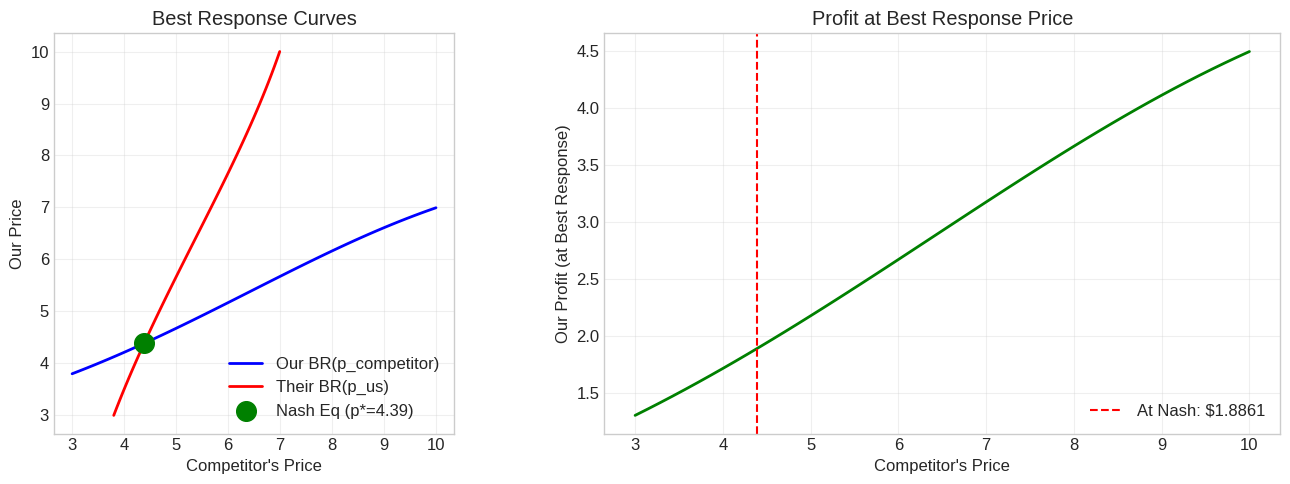

In [6]:
# Visualize Best Response Curves
comp_prices, our_br, profits = br_pricing.sensitivity_analysis(MARGINAL_COST_FORECAST)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best Response Curves
axes[0].plot(comp_prices, our_br, 'b-', linewidth=2, label='Our BR(p_competitor)')
axes[0].plot(our_br, comp_prices, 'r-', linewidth=2, label='Their BR(p_us)')
axes[0].scatter([ne_price], [ne_price], color='green', s=200, zorder=5,
               label=f'Nash Eq (p*={ne_price:.2f})')
axes[0].set_xlabel("Competitor's Price")
axes[0].set_ylabel("Our Price")
axes[0].set_title('Best Response Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Plot 2: Our Profit at Best Response
axes[1].plot(comp_prices, profits, 'g-', linewidth=2)
axes[1].axvline(x=ne_price, color='red', linestyle='--',
               label=f'At Nash: ${market.profit(ne_price, ne_price, MARGINAL_COST_FORECAST):.4f}')
axes[1].set_xlabel("Competitor's Price")
axes[1].set_ylabel("Our Profit (at Best Response)")
axes[1].set_title('Profit at Best Response Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Method 2: Bayesian Adaptive Learning

### Theory
Maintain a probability distribution over competitor's likely pricing behavior. As we observe their prices, update our beliefs using Bayes' rule:

$$P(\theta | data) \propto P(data | \theta) \cdot P(\theta)$$

Then optimize against the expected competitor behavior.

### Advantages
- Adapts to competitor behavior over time
- Quantifies uncertainty through confidence intervals
- Naturally incorporates prior knowledge

### Disadvantages
- Requires distributional assumptions
- Slow to adapt to sudden strategy changes
- Computationally more intensive

In [7]:
class BayesianAdaptivePricing:
    """
    Method 2: Bayesian Learning of Competitor Behavior
    """

    def __init__(self, market, prior_mean=5.0, prior_std=2.0):
        self.market = market
        self.prior_mean = prior_mean
        self.prior_std = prior_std

        # Current beliefs
        self.belief_mean = prior_mean
        self.belief_std = prior_std

        # History
        self.observed_prices = []

    def update_beliefs(self, observed_price, observation_noise=0.5):
        """Bayesian update using normal-normal conjugate prior."""
        self.observed_prices.append(observed_price)

        prior_precision = 1 / (self.belief_std ** 2)
        data_precision = 1 / (observation_noise ** 2)

        posterior_precision = prior_precision + data_precision
        posterior_mean = (prior_precision * self.belief_mean +
                         data_precision * observed_price) / posterior_precision
        posterior_std = np.sqrt(1 / posterior_precision)

        self.belief_mean = posterior_mean
        self.belief_std = posterior_std

        return posterior_mean, posterior_std

    def expected_profit(self, p_j, marginal_cost, n_samples=1000):
        """Monte Carlo estimate of expected profit."""
        samples = np.random.normal(self.belief_mean, self.belief_std, n_samples)
        samples = np.maximum(samples, 0.1)  # Price floor
        profits = [self.market.profit(p_j, s, marginal_cost) for s in samples]
        return np.mean(profits)

    def optimal_price(self, marginal_cost, price_bounds=(0.1, 20)):
        """Find price maximizing expected profit."""
        def neg_expected_profit(p_j):
            return -self.expected_profit(p_j, marginal_cost)

        result = minimize_scalar(neg_expected_profit, bounds=price_bounds, method='bounded')
        return result.x

    def get_confidence_interval(self, confidence=0.95):
        """Return CI for competitor's price."""
        z = norm.ppf((1 + confidence) / 2)
        return (max(0, self.belief_mean - z * self.belief_std),
                self.belief_mean + z * self.belief_std)

    def plot_belief_evolution(self):
        """Visualize how beliefs evolved over observations."""
        if not self.observed_prices:
            print("No observations yet.")
            return

        # Replay belief updates
        temp = BayesianAdaptivePricing(self.market, self.prior_mean, self.prior_std)
        means = [temp.belief_mean]
        stds = [temp.belief_std]

        for p in self.observed_prices:
            temp.update_beliefs(p)
            means.append(temp.belief_mean)
            stds.append(temp.belief_std)

        days = range(len(means))
        means, stds = np.array(means), np.array(stds)

        plt.figure(figsize=(10, 5))
        plt.plot(days, means, 'b-', linewidth=2, label='Belief Mean')
        plt.fill_between(days, means - 2*stds, means + 2*stds, alpha=0.3, label='95% CI')
        plt.scatter(range(1, len(self.observed_prices)+1), self.observed_prices,
                   color='red', s=100, zorder=5, label='Observed Prices')
        plt.xlabel('Day')
        plt.ylabel('Competitor Price Belief')
        plt.title('Bayesian Belief Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        return plt


# Initialize Bayesian learner
bayesian = BayesianAdaptivePricing(market, prior_mean=5.0, prior_std=2.0)

print("=" * 50)
print("METHOD 2: BAYESIAN ADAPTIVE PRICING")
print("=" * 50)
print(f"\nPrior belief: μ = {bayesian.belief_mean:.2f}, σ = {bayesian.belief_std:.2f}")

# Initial optimal price (before any observations)
initial_bayesian_price = bayesian.optimal_price(MARGINAL_COST_FORECAST)
ci = bayesian.get_confidence_interval()
print(f"\nOptimal price (no observations): ${initial_bayesian_price:.2f}")
print(f"95% CI for competitor: [{ci[0]:.2f}, {ci[1]:.2f}]")

METHOD 2: BAYESIAN ADAPTIVE PRICING

Prior belief: μ = 5.00, σ = 2.00

Optimal price (no observations): $5.17
95% CI for competitor: [1.08, 8.92]


In [8]:
# Simulate belief updates with example data
# Replace these with actual observed competitor prices as competition progresses

example_competitor_prices = [5.2, 4.8, 5.0]  # Example: Days 1-3

bayesian_demo = BayesianAdaptivePricing(market)

print("Bayesian Belief Updates (Example):")
print("-" * 40)
print(f"Prior: mean={bayesian_demo.belief_mean:.2f}, std={bayesian_demo.belief_std:.2f}")

for i, price in enumerate(example_competitor_prices):
    mean, std = bayesian_demo.update_beliefs(price)
    opt_price = bayesian_demo.optimal_price(MARGINAL_COST_FORECAST)
    print(f"After Day {i+1} (observed p={price:.2f}): "
          f"belief={mean:.2f}±{std:.2f}, optimal=${opt_price:.2f}")

Bayesian Belief Updates (Example):
----------------------------------------
Prior: mean=5.00, std=2.00
After Day 1 (observed p=5.20): belief=5.19±0.49, optimal=$4.90
After Day 2 (observed p=4.80): belief=5.00±0.35, optimal=$4.80
After Day 3 (observed p=5.00): belief=5.00±0.29, optimal=$4.76


## 5. Method 3: Thompson Sampling (Multi-Armed Bandit)

### Theory
Treat each discrete price level as an "arm". Maintain beliefs about expected profit at each price. Use Thompson Sampling to select prices that balance:
- **Exploitation**: Choose prices we believe are optimal
- **Exploration**: Try uncertain prices to learn more

### Advantages
- Automatically balances exploration vs exploitation
- Robust to non-stationary environments
- No need to explicitly model competitor

### Disadvantages
- Requires discretizing price space
- May explore suboptimal prices early on
- Needs many observations for convergence

In [9]:
class ThompsonSamplingPricing:
    """
    Method 3: Thompson Sampling for Price Exploration
    """

    def __init__(self, market, price_min=2.0, price_max=12.0, n_levels=21):
        self.market = market
        self.price_levels = np.linspace(price_min, price_max, n_levels)
        self.n_arms = len(self.price_levels)

        # Prior beliefs: mean=1, std=2 for each arm
        self.means = np.ones(self.n_arms) * 1.0
        self.stds = np.ones(self.n_arms) * 2.0
        self.n_plays = np.zeros(self.n_arms)

        # History
        self.history = []

    def select_price(self):
        """Thompson Sampling: sample from posteriors, pick best."""
        samples = np.random.normal(self.means, self.stds)
        best_arm = np.argmax(samples)
        return self.price_levels[best_arm], best_arm

    def update(self, arm_idx, observed_profit):
        """Update beliefs after observing profit."""
        self.n_plays[arm_idx] += 1
        n = self.n_plays[arm_idx]

        # Incremental mean update
        old_mean = self.means[arm_idx]
        self.means[arm_idx] = old_mean + (observed_profit - old_mean) / n

        # Reduce uncertainty
        self.stds[arm_idx] = max(0.1, self.stds[arm_idx] * 0.9)

        self.history.append({
            'arm': arm_idx,
            'price': self.price_levels[arm_idx],
            'profit': observed_profit
        })

    def get_best_price(self):
        """Return current best estimate."""
        return self.price_levels[np.argmax(self.means)]

    def plot_beliefs(self):
        """Visualize current beliefs."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Expected profits
        axes[0].bar(self.price_levels, self.means, width=0.4, alpha=0.7, color='steelblue')
        axes[0].errorbar(self.price_levels, self.means, yerr=self.stds,
                        fmt='none', color='darkblue', capsize=3)
        axes[0].set_xlabel('Price Level')
        axes[0].set_ylabel('Expected Profit')
        axes[0].set_title('Thompson Sampling: Profit Beliefs')
        axes[0].grid(True, alpha=0.3)

        # Exploration pattern
        axes[1].bar(self.price_levels, self.n_plays, width=0.4, alpha=0.7, color='coral')
        axes[1].set_xlabel('Price Level')
        axes[1].set_ylabel('Times Played')
        axes[1].set_title('Exploration Pattern')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig


# Initialize Thompson Sampling
thompson = ThompsonSamplingPricing(market)

print("=" * 50)
print("METHOD 3: THOMPSON SAMPLING")
print("=" * 50)
print(f"\nPrice levels: {len(thompson.price_levels)} discrete prices from "
      f"${thompson.price_levels[0]:.1f} to ${thompson.price_levels[-1]:.1f}")

# Sample a few prices to see exploration
print("\nSample selections (before any observations):")
for i in range(5):
    price, arm = thompson.select_price()
    print(f"  Selection {i+1}: ${price:.2f}")

METHOD 3: THOMPSON SAMPLING

Price levels: 21 discrete prices from $2.0 to $12.0

Sample selections (before any observations):
  Selection 1: $3.00
  Selection 2: $6.50
  Selection 3: $5.00
  Selection 4: $3.50
  Selection 5: $6.50


## 6. Method Comparison and Recommendation

### Summary Table

| Method | Best For | Requires | Risk Level |
|--------|----------|----------|------------|
| Best Response | Known competitor price | Price estimate | Low (if estimate good) |
| Bayesian | Learning competitor | Historical data | Medium |
| Thompson Sampling | Uncertain environment | Profit feedback | Higher early, lower later |

In [10]:
def compare_methods(marginal_cost, competitor_price_estimate=None):
    """
    Compare all three methods side by side.
    """
    results = {}

    # Nash Equilibrium
    br = BestResponsePricing(market)
    ne_price, _ = br.compute_nash_equilibrium(marginal_cost)
    results['Nash Equilibrium'] = ne_price

    # Best Response (if we have estimate)
    if competitor_price_estimate:
        br_price = br.best_response(competitor_price_estimate, marginal_cost)
        results['Best Response'] = br_price

    # Bayesian (using prior)
    bay = BayesianAdaptivePricing(market)
    bay_price = bay.optimal_price(marginal_cost)
    results['Bayesian (prior)'] = bay_price

    # Thompson Sampling
    ts = ThompsonSamplingPricing(market)
    ts_price, _ = ts.select_price()
    results['Thompson Sampling'] = ts_price

    return results


# Run comparison
print("=" * 60)
print("METHOD COMPARISON")
print("=" * 60)
print(f"\nMarginal Cost = ${MARGINAL_COST_FORECAST}")
print("\nRecommended Prices:")
print("-" * 40)

comparison = compare_methods(MARGINAL_COST_FORECAST, competitor_price_estimate=5.0)
for method, price in comparison.items():
    print(f"  {method:25s}: ${price:.2f}")

METHOD COMPARISON

Marginal Cost = $0.5

Recommended Prices:
----------------------------------------
  Nash Equilibrium         : $4.39
  Best Response            : $4.67
  Bayesian (prior)         : $5.24
  Thompson Sampling        : $10.00


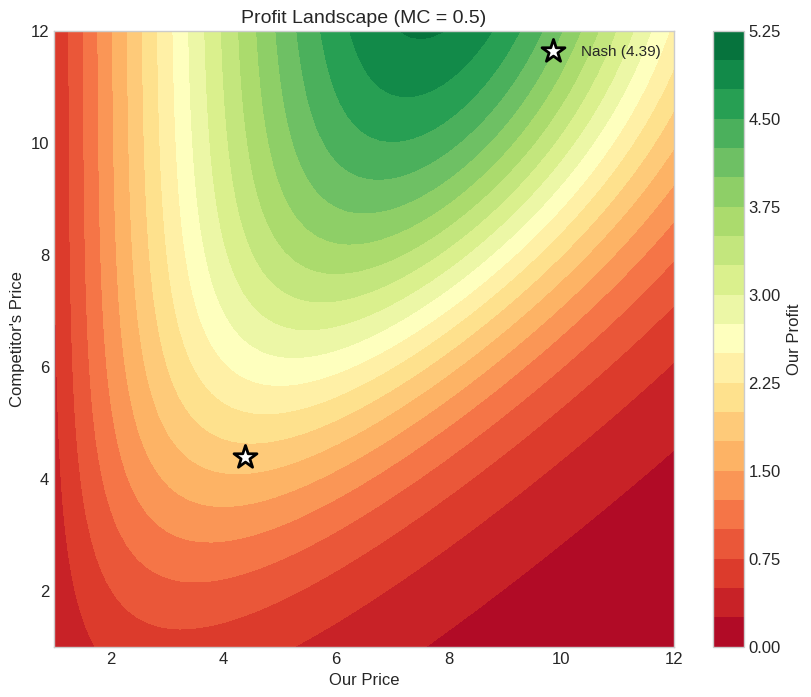

In [11]:
# Profit landscape visualization
our_prices = np.linspace(1, 12, 60)
comp_prices = np.linspace(1, 12, 60)
P_us, P_them = np.meshgrid(our_prices, comp_prices)
Profits = np.zeros_like(P_us)

for i in range(len(comp_prices)):
    for j in range(len(our_prices)):
        Profits[i, j] = market.profit(P_us[i, j], P_them[i, j], MARGINAL_COST_FORECAST)

fig, ax = plt.subplots(figsize=(10, 8))
cs = ax.contourf(P_us, P_them, Profits, levels=20, cmap='RdYlGn')
plt.colorbar(cs, label='Our Profit')

# Mark Nash equilibrium
ne_price, _ = br_pricing.compute_nash_equilibrium(MARGINAL_COST_FORECAST)
ax.scatter([ne_price], [ne_price], color='white', s=300, marker='*',
          edgecolors='black', linewidths=2, label=f'Nash ({ne_price:.2f})')

ax.set_xlabel("Our Price", fontsize=12)
ax.set_ylabel("Competitor's Price", fontsize=12)
ax.set_title(f'Profit Landscape (MC = {MARGINAL_COST_FORECAST})', fontsize=14)
ax.legend(fontsize=11)
plt.show()

## 7. Daily Price Calculator

**Use this section each day to get your price recommendation!**

Update the inputs below with current data and run the cell.

In [12]:
#Jocelyn_Day2 Update

# ============================================================
# DAILY INPUTS - UPDATE THESE EACH DAY
# ============================================================

DAY_NUMBER = 2  # 1=Thursday, 2=Friday, 3=Saturday, etc.

# Today's marginal cost forecast
MC_TODAY = 0.7

# Historical data (update as you get results)
# Format: [(our_price, competitor_price, realized_profit), ...]
HISTORY = [
    (4.25, 4.38, 1.8811)
    # Example: (5.0, 5.2, 0.85),  # Day 1 results
    # Add more as days pass
]

# ============================================================
# CALCULATION (run this cell after updating inputs)
# ============================================================
def daily_recommendation(day, mc, history):
    """
    Improved daily pricing recommendation.

    Logic:
    1. If no history, use Nash equilibrium as the default.
    2. If history exists, use yesterday's observed competitor price
       to compute today's best response under today's marginal cost.
    3. Add a simple robustness adjustment based on competitor aggressiveness.
    4. Print scenario analysis for nearby competitor prices.
    """
    print("\n" + "=" * 60)
    print(f"DAY {day} PRICING RECOMMENDATION")
    print("=" * 60)
    print(f"Marginal Cost Forecast: ${mc:.2f}")

    br = BestResponsePricing(market)
    bayesian = BayesianAdaptivePricing(market)
    thompson = ThompsonSamplingPricing(market)

    # Update models with historical data
    if history:
        print(f"\nHistorical Data ({len(history)} days):")
        for i, (our_p, comp_p, profit) in enumerate(history):
            print(f"  Day {i+1}: Our=${our_p:.2f}, Comp=${comp_p:.2f}, Profit=${profit:.4f}")
            bayesian.update_beliefs(comp_p)
            arm_idx = np.argmin(np.abs(thompson.price_levels - our_p))
            thompson.update(arm_idx, profit)

    ne_price, _ = br.compute_nash_equilibrium(mc)
    bayesian_price = bayesian.optimal_price(mc)

    print("\n" + "-" * 40)
    print("REFERENCE PRICES:")
    print("-" * 40)
    print(f"  Nash Equilibrium:    ${ne_price:.2f}")
    print(f"  Bayesian Optimal:    ${bayesian_price:.2f}")

    # Case 1: No history yet -> use Nash as default
    if not history:
        recommended = ne_price
        strategy = "No history yet: use Nash equilibrium as baseline"
        print("\n" + "*" * 40)
        print(f">>> RECOMMENDED PRICE: ${recommended:.2f}")
        print(f">>> Strategy: {strategy}")
        print("*" * 40)
        return recommended

    # Case 2: We have history -> use yesterday's observed competitor price
    last_our, last_comp, last_profit = history[-1]

    br_to_last_comp = br.best_response(last_comp, mc)

    # Measure whether competitor seemed aggressive yesterday
    # If competitor priced much lower than Nash, treat as aggressive
    aggressive_threshold = 0.90 * ne_price
    competitor_aggressive = last_comp < aggressive_threshold

    # Robust adjustment rules
    if competitor_aggressive:
        # Do not fully jump to BR if competitor seems aggressive
        # Blend BR with yesterday competitor price to stay safer
        recommended = 0.7 * br_to_last_comp + 0.3 * last_comp
        strategy = (
            "Competitor appeared aggressive yesterday: "
            "use cautious best response blended with observed competitor price"
        )
    else:
        # If competitor was not aggressive, use direct BR
        recommended = br_to_last_comp
        strategy = (
            "Use best response to yesterday's observed competitor price "
            "under today's marginal cost"
        )

    # Optional rounding for cleaner submitted price
    recommended = round(recommended, 2)

    print("\n" + "-" * 40)
    print("MODEL-BASED DECISION:")
    print("-" * 40)
    print(f"  Yesterday competitor price: ${last_comp:.2f}")
    print(f"  Best response to last competitor price: ${br_to_last_comp:.2f}")
    print(f"  Competitor aggressive? {'Yes' if competitor_aggressive else 'No'}")

    print("\n" + "*" * 40)
    print(f">>> RECOMMENDED PRICE: ${recommended:.2f}")
    print(f">>> Strategy: {strategy}")
    print("*" * 40)

    # Expected outcome if competitor stays unchanged
    exp_demand = market.demand(recommended, last_comp)
    exp_profit = market.profit(recommended, last_comp, mc)

    print(f"\nIf competitor stays at ${last_comp:.2f}:")
    print(f"  Expected Demand: {exp_demand:.4f}")
    print(f"  Expected Profit: ${exp_profit:.4f}")

    # Scenario analysis around competitor movement
    scenario_comp_prices = [
        round(last_comp - 0.25, 2),
        round(last_comp, 2),
        round(last_comp + 0.25, 2)
    ]

    print("\nScenario analysis:")
    for cp in scenario_comp_prices:
        d = market.demand(recommended, cp)
        p = market.profit(recommended, cp, mc)
        print(f"  If competitor = ${cp:.2f}: Demand = {d:.4f}, Profit = ${p:.4f}")

    return recommended


# Run daily recommendation
todays_price = daily_recommendation(DAY_NUMBER, MC_TODAY, HISTORY)


DAY 2 PRICING RECOMMENDATION
Marginal Cost Forecast: $0.70

Historical Data (1 days):
  Day 1: Our=$4.25, Comp=$4.38, Profit=$1.8811

----------------------------------------
REFERENCE PRICES:
----------------------------------------
  Nash Equilibrium:    $4.58
  Bayesian Optimal:    $4.53

----------------------------------------
MODEL-BASED DECISION:
----------------------------------------
  Yesterday competitor price: $4.38
  Best response to last competitor price: $4.49
  Competitor aggressive? No

****************************************
>>> RECOMMENDED PRICE: $4.49
>>> Strategy: Use best response to yesterday's observed competitor price under today's marginal cost
****************************************

If competitor stays at $4.38:
  Expected Demand: 0.4717
  Expected Profit: $1.7876

Scenario analysis:
  If competitor = $4.13: Demand = 0.4423, Profit = $1.6764
  If competitor = $4.38: Demand = 0.4717, Profit = $1.7876
  If competitor = $4.63: Demand = 0.5010, Profit = $1.8

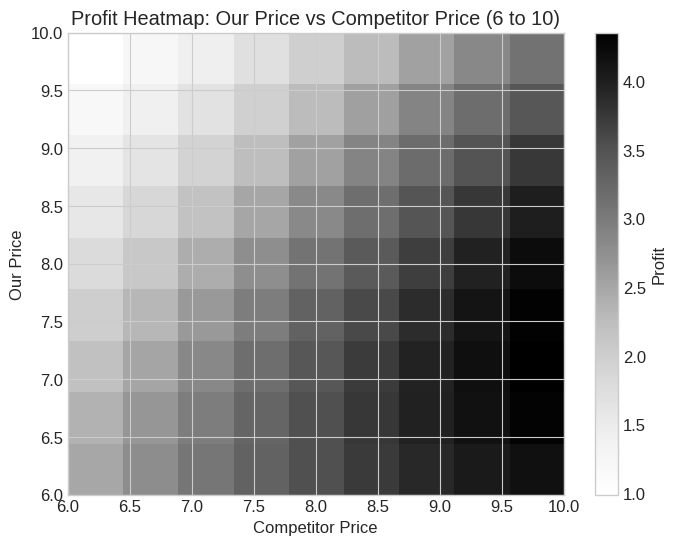

GRID TEST RESULT
Best our price in grid:        $7.00
Best competitor price in grid: $10.00
Best profit in grid:           4.3561


In [13]:
def aggressive_price_grid_test(market, mc=0.7, price_min=6.0, price_max=10.0, step=0.5):
    """
    Grid test:
    our price in [6,10], competitor price in [6,10]
    """
    our_prices = np.arange(price_min, price_max + step, step)
    comp_prices = np.arange(price_min, price_max + step, step)

    profit_matrix = np.zeros((len(our_prices), len(comp_prices)))

    for i, our_p in enumerate(our_prices):
        for j, comp_p in enumerate(comp_prices):
            profit_matrix[i, j] = market.profit(our_p, comp_p, mc)

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(
        profit_matrix,
        origin="lower",
        aspect="auto",
        extent=[comp_prices.min(), comp_prices.max(), our_prices.min(), our_prices.max()]
    )
    plt.colorbar(label="Profit")
    plt.xlabel("Competitor Price")
    plt.ylabel("Our Price")
    plt.title("Profit Heatmap: Our Price vs Competitor Price (6 to 10)")
    plt.show()

    # Best combination in the grid
    max_idx = np.unravel_index(np.argmax(profit_matrix), profit_matrix.shape)
    best_our = our_prices[max_idx[0]]
    best_comp = comp_prices[max_idx[1]]
    best_profit = profit_matrix[max_idx]

    print("=" * 70)
    print("GRID TEST RESULT")
    print("=" * 70)
    print(f"Best our price in grid:        ${best_our:.2f}")
    print(f"Best competitor price in grid: ${best_comp:.2f}")
    print(f"Best profit in grid:           {best_profit:.4f}")

    return profit_matrix, our_prices, comp_prices

profit_matrix, our_prices, comp_prices = aggressive_price_grid_test(market, mc=0.7)

In [14]:
# ============================================================
# DAILY INPUTS - UPDATE THESE EACH DAY
# ============================================================

DAY_NUMBER = 2  # 1=Thursday, 2=Friday, 3=Saturday, etc.

# Today's marginal cost forecast
MC_TODAY = 0.7

# Historical data (update as you get results)
# Format: [(our_price, competitor_price, realized_profit), ...]
HISTORY = [
    (4.25, 4.38, 1.8811)
    # Example: (5.0, 5.2, 0.85),  # Day 1 results
    # Add more as days pass
]

# ============================================================
# CALCULATION (run this cell after updating inputs)
# ============================================================
def daily_recommendation(day, mc, history):
    """
    Generate price recommendation based on current state.
    """
    print("\n" + "=" * 60)
    print(f"DAY {day} PRICING RECOMMENDATION")
    print("=" * 60)
    print(f"Marginal Cost Forecast: ${mc:.2f}")

    # Initialize methods
    br = BestResponsePricing(market)
    bayesian = BayesianAdaptivePricing(market)
    thompson = ThompsonSamplingPricing(market)

    # Update with historical data
    if history:
        print(f"\nHistorical Data ({len(history)} days):")
        for i, (our_p, comp_p, profit) in enumerate(history):
            print(f"  Day {i+1}: Our=${our_p:.2f}, Comp=${comp_p:.2f}, Profit=${profit:.4f}")
            bayesian.update_beliefs(comp_p)
            arm_idx = np.argmin(np.abs(thompson.price_levels - our_p))
            thompson.update(arm_idx, profit)

    # Get recommendations
    ne_price, _ = br.compute_nash_equilibrium(mc)
    bayesian_price = bayesian.optimal_price(mc)
    ts_price, _ = thompson.select_price()

    print("\n" + "-" * 40)
    print("RECOMMENDATIONS BY METHOD:")
    print("-" * 40)
    print(f"  Nash Equilibrium:    ${ne_price:.2f}")
    print(f"  Bayesian Optimal:    ${bayesian_price:.2f}")
    print(f"  Thompson Sampling:   ${ts_price:.2f}")

    # Strategy logic
    if day <= 2:
        recommended = ne_price * 0.97  # Slight undercut early
        strategy = "Early game: Nash with 3% undercut for market capture"
    elif day <= 5:
        recommended = bayesian_price
        strategy = "Mid game: Bayesian optimization based on learned behavior"
    else:
        if history and history[-1][1] < ne_price * 0.9:  # Competitor aggressive
            recommended = history[-1][1] * 0.98
            strategy = "Late game: Aggressive response to competitor undercut"
        else:
            recommended = bayesian_price
            strategy = "Late game: Full Bayesian optimization"

    print("\n" + "*" * 40)
    print(f">>> RECOMMENDED PRICE: ${recommended:.2f}")
    print(f">>> Strategy: {strategy}")
    print("*" * 40)

    # Expected outcomes
    if history:
        last_comp = history[-1][1]
        exp_demand = market.demand(recommended, last_comp)
        exp_profit = market.profit(recommended, last_comp, mc)
        print(f"\nIf competitor unchanged at ${last_comp:.2f}:")
        print(f"  Expected Demand: {exp_demand:.4f}")
        print(f"  Expected Profit: ${exp_profit:.4f}")

    return recommended


# Run daily recommendation
todays_price = daily_recommendation(DAY_NUMBER, MC_TODAY, HISTORY)


DAY 2 PRICING RECOMMENDATION
Marginal Cost Forecast: $0.70

Historical Data (1 days):
  Day 1: Our=$4.25, Comp=$4.38, Profit=$1.8811

----------------------------------------
RECOMMENDATIONS BY METHOD:
----------------------------------------
  Nash Equilibrium:    $4.58
  Bayesian Optimal:    $4.42
  Thompson Sampling:   $3.50

****************************************
>>> RECOMMENDED PRICE: $4.44
>>> Strategy: Early game: Nash with 3% undercut for market capture
****************************************

If competitor unchanged at $4.38:
  Expected Demand: 0.4781
  Expected Profit: $1.7873


## 8. Simulation: Test Your Strategy

Run simulations against different competitor strategies to understand performance.

In [15]:
def simulate_week(our_strategy='bayesian', competitor_strategy='nash', mc_schedule=None):
    """
    Simulate a full week of competition.

    our_strategy: 'nash', 'bayesian', 'thompson', 'aggressive'
    competitor_strategy: 'nash', 'aggressive', 'random', 'mirror'
    """
    if mc_schedule is None:
        mc_schedule = [0.5, 0.7, 0.4, 0.55, 0.5, 0.45, 0.5]

    n_days = len(mc_schedule)

    # Initialize
    br = BestResponsePricing(market)
    bayesian = BayesianAdaptivePricing(market)
    thompson = ThompsonSamplingPricing(market)

    results = []
    our_cumulative = 0
    comp_cumulative = 0

    for day in range(n_days):
        mc = mc_schedule[day]

        # Competitor's price
        ne_price, _ = br.compute_nash_equilibrium(mc)
        if competitor_strategy == 'nash':
            comp_price = ne_price
        elif competitor_strategy == 'aggressive':
            comp_price = ne_price * 0.9
        elif competitor_strategy == 'random':
            comp_price = np.random.uniform(3, 8)
        else:  # mirror
            comp_price = results[-1]['our_price'] if results else ne_price

        # Our price
        if our_strategy == 'nash':
            our_price = ne_price
        elif our_strategy == 'bayesian':
            our_price = bayesian.optimal_price(mc)
        elif our_strategy == 'thompson':
            our_price, _ = thompson.select_price()
        else:  # aggressive
            our_price = ne_price * 0.92

        # Calculate outcomes
        our_profit = market.profit(our_price, comp_price, mc)
        comp_profit = market.profit(comp_price, our_price, mc)

        our_cumulative += our_profit
        comp_cumulative += comp_profit

        results.append({
            'day': day + 1,
            'mc': mc,
            'our_price': our_price,
            'comp_price': comp_price,
            'our_profit': our_profit,
            'comp_profit': comp_profit
        })

        # Update learning algorithms
        bayesian.update_beliefs(comp_price)
        arm_idx = np.argmin(np.abs(thompson.price_levels - our_price))
        thompson.update(arm_idx, our_profit)

    return results, our_cumulative, comp_cumulative


# Run simulations against different strategies
print("=" * 60)
print("SIMULATION RESULTS: BAYESIAN vs VARIOUS COMPETITORS")
print("=" * 60)

for comp_strat in ['nash', 'aggressive', 'random', 'mirror']:
    results, our_total, comp_total = simulate_week('bayesian', comp_strat)
    winner = "US" if our_total > comp_total else "THEM"
    print(f"\nvs {comp_strat.upper():12s}: Our Total=${our_total:.4f}, "
          f"Their Total=${comp_total:.4f} → Winner: {winner}")

SIMULATION RESULTS: BAYESIAN vs VARIOUS COMPETITORS

vs NASH        : Our Total=$13.1163, Their Total=$13.7378 → Winner: THEM

vs AGGRESSIVE  : Our Total=$11.7339, Their Total=$13.0419 → Winner: THEM

vs RANDOM      : Our Total=$17.0087, Their Total=$12.6760 → Winner: US

vs MIRROR      : Our Total=$13.7295, Their Total=$13.9469 → Winner: THEM


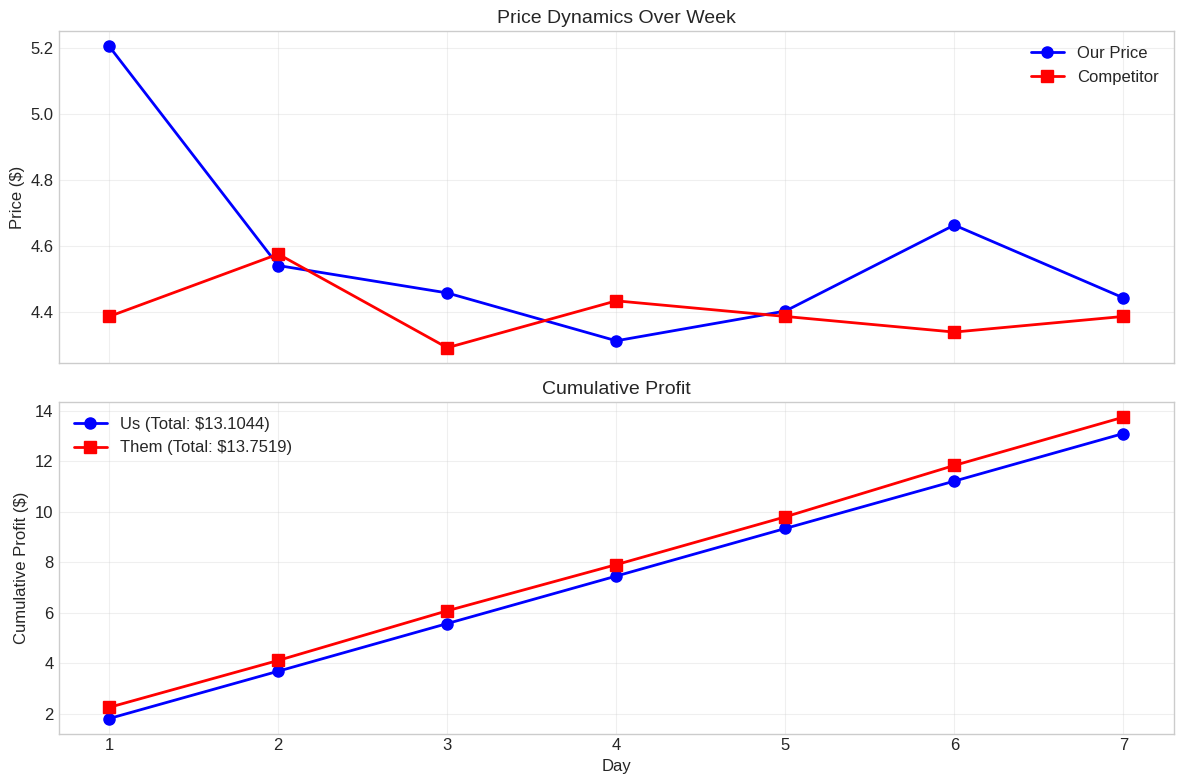

In [16]:
# Detailed simulation visualization
results, our_total, comp_total = simulate_week('bayesian', 'nash')

days = [r['day'] for r in results]
our_prices = [r['our_price'] for r in results]
comp_prices = [r['comp_price'] for r in results]
our_profits = [r['our_profit'] for r in results]
comp_profits = [r['comp_profit'] for r in results]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Prices over time
axes[0].plot(days, our_prices, 'b-o', linewidth=2, markersize=8, label='Our Price')
axes[0].plot(days, comp_prices, 'r-s', linewidth=2, markersize=8, label='Competitor')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title('Price Dynamics Over Week', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative profits
our_cum = np.cumsum(our_profits)
comp_cum = np.cumsum(comp_profits)
axes[1].plot(days, our_cum, 'b-o', linewidth=2, markersize=8, label=f'Us (Total: ${our_total:.4f})')
axes[1].plot(days, comp_cum, 'r-s', linewidth=2, markersize=8, label=f'Them (Total: ${comp_total:.4f})')
axes[1].set_xlabel('Day', fontsize=12)
axes[1].set_ylabel('Cumulative Profit ($)', fontsize=12)
axes[1].set_title('Cumulative Profit', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Final Recommendations

### Strategy by Day

| Day | Stage | Recommended Method | Rationale |
|-----|-------|-------------------|------------|
| 1-2 | Early | Nash - 3% | Limited data, establish position |
| 3-5 | Learning | Bayesian | Adapt to observed competitor behavior |
| 6-7 | Optimize | Bayesian/Aggressive | Maximize final profit |

### Key Insights

1. **Best Response** is optimal if you can accurately predict competitor's price
2. **Bayesian** excels as you accumulate observations
3. **Thompson Sampling** is safest when environment is highly uncertain

### Recommendation

We recommend the **Hybrid Approach**:
- Start conservative (near Nash)
- Transition to Bayesian as data accumulates
- Adjust aggressiveness based on standing in competition

In [17]:
# Final summary
print("\n" + "=" * 60)
print("FINAL STRATEGY SUMMARY")
print("=" * 60)

print("""
╔══════════════════════════════════════════════════════════╗
║              RECOMMENDED PRICING STRATEGY                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Day 1-2: Nash Equilibrium × 0.97 (slight undercut)     ║
║           → Establish market position                    ║
║                                                          ║
║  Day 3-5: Bayesian Optimal Price                        ║
║           → Adapt to learned competitor behavior         ║
║                                                          ║
║  Day 6-7: Bayesian OR Aggressive (if behind)            ║
║           → Maximize final week profit                   ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝

KEY REMINDERS:
• Update competitor prices daily in the HISTORY variable
• Run daily_recommendation() each day for updated advice
• Monitor cumulative profit to adjust aggressiveness
• Submit prices before midnight!
""")


FINAL STRATEGY SUMMARY

╔══════════════════════════════════════════════════════════╗
║              RECOMMENDED PRICING STRATEGY                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Day 1-2: Nash Equilibrium × 0.97 (slight undercut)     ║
║           → Establish market position                    ║
║                                                          ║
║  Day 3-5: Bayesian Optimal Price                        ║
║           → Adapt to learned competitor behavior         ║
║                                                          ║
║  Day 6-7: Bayesian OR Aggressive (if behind)            ║
║           → Maximize final week profit                   ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝

KEY REMINDERS:
• Update competitor prices daily in the HISTORY variable
• Run daily_recommendation() each day for updated 